# 3. Méthodes d'agrégation : Bagging

## 3.1 Définition de Bagging

**Bagging** signifie **Bootstrap Aggregating** :
- **Bootstrap** = tirer aléatoirement avec remise plusieurs sous-échantillons d'individus.
- **Aggregating** = combiner les prédictions (moyenne pour la régression, vote pour la classification).

L'idée clé est de :

- 👉 Créer plusieurs jeux de données légèrement différents,
- 👉 Entraîner un modèle différent sur chaque jeu,
- 👉 Puis agréger leurs prédictions.

## 3.2 Comment fonctionne Bagging ?

1. **Échantillonnage d'individus** avec remise (Bootstrap).
2. **Entraînement indépendant** de plusieurs modèles.
3. **Agrégation** : moyenne (régression) ou vote majoritaire (classification).

Schéma :
```
Jeu de données initial
       |
+-------------+------------------+
|             |                  |
Échantillon 1 Échantillon 2 Échantillon 3
(bootstrap)   (bootstrap)   (bootstrap)
|             |                  |
Arbre 1     Arbre 2          Arbre 3
\             |                 /
  Agrégation (Vote ou Moyenne)
```

## 3.3 Pourquoi Bagging réduit la variance ?

- Chaque modèle a une forte variance.
- En **moyennant/votant les prédictions** de plusieurs modèles, on réduit les erreurs spécifiques à chacun.
- Résultat : un modèle plus **robuste** et **moins sensible** aux variations du jeu d'entraînement.


## 3.4 Autres exemples de Bagging

Bagging peut être appliqué à :
- des **arbres de décision** (Bagging classique),
- des **régressions logistiques**,
- des **k plus proches voisins (kNN)**,
- même à des **réseaux de neurones simples**.

Mais Bagging est particulièrement efficace pour des modèles **instables** comme les arbres.

## 🌳 3.5 Pourquoi les arbres peuvent se ressembler en Bagging simple ?  

### 📝 Bagging classique :  
- Chaque arbre utilise **toutes les variables** disponibles.  
- Si certaines variables sont **très fortes** (prédictives), **tous les arbres** auront tendance à faire **les mêmes coupures**.  
- Résultat : **arbres corrélés**, la réduction de variance est donc moins efficace.  

---

### 🍏🍐 **Exemple concret : Pommes et Poires**  

| Poids (g) | Diamètre (cm) | Couleur (score 0–1) | Fruit  |
|-----------|--------------|---------------------|-------|
| 150       | 7.5          | 0.7                 | Pomme |
| 155       | 7.6          | 0.6                 | Pomme |
| 160       | 7.8          | 0.4                 | Poire |
| 165       | 8.0          | 0.5                 | Poire |
| 170       | 8.1          | 0.8                 | Pomme |
| 175       | 8.3          | 0.3                 | Poire |

---

#### 🌟 **Pourquoi les arbres se ressemblent-ils ?**  
Imaginons que la variable **Couleur** soit très forte pour prédire le fruit :  
- Si tous les arbres utilisent cette variable en priorité, **ils feront tous la même coupure** (par exemple, **Couleur > 0.65** ou **Couleur > 0.55** ou d'autres seuils proches pour séparer les Pommes des Poires).  
- **L'arbre corrélé en Bagging est surtout lié à la structure de l'arbre plutôt qu'à la valeur exacte de la coupure.**  
- Ensuite, bien que des coupures secondaires puissent différer (sur **Poids** ou **Diamètre**), **l'essentiel de la séparation est déjà réalisé**.  
- **Même si les coupures secondaires diffèrent**, les arbres restent **fortement corrélés** car la **première coupure reste la même** ou est **très proche**.  

---

### ✅ **Réponse aux étudiants :**  
Même si les arbres peuvent avoir des coupures secondaires différentes, **la première coupure est déterminante** car elle sépare **l'espace des données en deux grandes régions** :  
- Une fois cette **première coupure réalisée**, les sous-groupes sont **déjà homogènes** ou presque.  
- Les coupures suivantes, appliquées à des **petits sous-groupes** déjà bien séparés, ont un impact moindre.  
- C’est pourquoi, même si la structure des arbres varie légèrement après la première coupure, **ils restent fortement similaires** et donc **corrélés**.  

---

### 🧠 **En quoi la corrélation pose problème ?**  
En **Bagging**, l'objectif est de réduire la **variance** en combinant plusieurs modèles. Cependant, si les arbres sont **fortement corrélés** (par exemple, en raison de l’utilisation répétée des mêmes variables très prédictives), ils vont faire **les mêmes erreurs** sur des zones similaires des données.  
- Cela réduit l'**indépendance** entre les modèles, ce qui empêche **Bagging** de réduire efficacement la variance.  
- En conséquence, la **combinaison des prédictions** ne bénéficie pas de la diversité nécessaire pour améliorer les performances.  

---

### 🌲 **Solution : Random Forest**  
Pour réduire cette corrélation, l'algorithme **Random Forest** sélectionne **aléatoirement un sous-ensemble de variables** à chaque coupure.  
- Cela permet d'éviter que la **variable la plus prédictive** soit systématiquement choisie en premier.  
- Les arbres deviennent alors **plus diversifiés**, ce qui améliore la **réduction de variance**.  


---

# 4. 🌲🌲🌲🌲 Random Forest

## 4.1 📘 Définition

Une **Random Forest** est une **forêt d'arbres de décision**, construite selon deux principes :

- 🎲 **Tirage bootstrap** des individus (échantillons aléatoires avec remise),
- 🎯 **Sélection aléatoire de variables** à chaque nœud.

Chaque arbre pousse **indépendamment**, avec moins d'information à chaque décision,  
ce qui permet :
- 👉 **plus de diversité** entre les arbres,
- ✅ donc une **réduction de la variance** du modèle global.

---

## 4.2 🧠 Comment sont choisies les variables ?

À chaque nœud de chaque arbre :

- On dispose de `d` variables explicatives au total.
- On tire au hasard `k` variables parmi les `d`.
- Et **on ne regarde que ces `k` variables** pour trouver la meilleure coupure.

---

#### 📐 Règles classiques :

- En **classification** :

  $$
  k = \sqrt{d}
  $$

- En **régression** :

  $$
  k = \frac{d}{3}
  $$

---

#### 🧪 Exemple :

- Si $d = 9$ variables ➝ alors $k \approx 3$ variables testées **par nœud**.
- Ce tirage est **aléatoire et indépendant à chaque nœud**.



## 4.3 🍏🍐 Exemple concret : Random Forest (Pommes / Poires)

Voici un petit jeu de données :

| Poids (g) | Diamètre (cm) | Couleur (score 0–1) | Fruit  |
|:---------:|:-------------:|:-------------------:|:------:|
| 150       | 7.5           | 0.7                 | Pomme  |
| 155       | 7.6           | 0.6                 | Pomme  |
| 160       | 7.8           | 0.4                 | Poire  |
| 165       | 8.0           | 0.5                 | Poire  |
| 170       | 8.1           | 0.8                 | Pomme  |
| 175       | 8.3           | 0.3                 | Poire  |

---

### 🌲 **Arbre 1**  

- **Bootstrap tiré** : 150, 155, 160, 165, 170, 175  
- **Variables sélectionnées** : Poids, Couleur  
- **Coupure choisie** : `Couleur > 0.65`  

| Groupe | Condition             | Fruits           | Classe majoritaire |
|-------|------------------------|------------------|--------------------|
| 1     | Couleur ≤ 0.65         | 155, 160, 165, 175| Poire               |
| 2     | Couleur > 0.65         | 150, 170          | Pomme               |

✅ **Séparation correcte (Couleur prédictive)**  

---

### 🌳 **Arbre 2**  

- **Bootstrap tiré** : 150, 155, 165, 170, 170, 175  
- **Variables sélectionnées** : Diamètre, Couleur  
- **Coupure choisie** : `Diamètre > 8.0`  

| Groupe | Condition           | Fruits           | Classe majoritaire |
|-------|----------------------|------------------|--------------------|
| 1     | Diamètre ≤ 8.0       | 150, 155, 165     | Pomme               |
| 2     | Diamètre > 8.0       | 170, 170, 175     | Pomme               |

⚠️ **Séparation imparfaite (mélange de Pommes/Poires)**  

---

### 🌲 **Arbre 3**  

- **Bootstrap tiré** : 155, 160, 165, 170, 170, 175  
- **Variables sélectionnées** : Poids, Diamètre  
- **Coupure choisie** : `Poids > 165`  

| Groupe | Condition         | Fruits           | Classe majoritaire |
|-------|--------------------|------------------|--------------------|
| 1     | Poids ≤ 165        | 155, 160, 165     | Poire               |
| 2     | Poids > 165        | 170, 170, 175     | Pomme               |

✅ **Séparation correcte (Poids pertinent)**  

---

### 🧠 **Remarques**  

- Les arbres sont **diversifiés** grâce à :  
  - L'échantillonnage **Bootstrap** (les arbres n'ont pas les mêmes données)  
  - La sélection aléatoire de **variables** (les arbres n'ont pas les mêmes attributs)  
- Cette diversité permet au **Random Forest** d'être plus **robuste** et moins sujet au **surapprentissage**.  
- En combinant les prédictions (par **vote** ou **moyenne**), l'ensemble est **plus précis** qu'un seul arbre.  

---

### ✅ **Pourquoi cette approche est-elle efficace ?**  
- **Diminution de la variance :** Les erreurs individuelles des arbres sont **lissées** par l'agrégation.  
- **Meilleure robustesse :** Même si un arbre se trompe, les autres peuvent corriger.  
- **Moins de surapprentissage :** La diversité des arbres permet d'éviter un **ajustement excessif** aux données d'entraînement.  


## 4.4 Résumé Bagging vs Random Forest

| Critère | Bagging | Random Forest |
|---------|---------|---------------|
| Bootstrap des individus |       🟢   |   🟢   |
| Sélection aléatoire de variables |       🔴 |   🟢   |
| Objectif principal | Réduire la variance | Réduire variance + corrélation |

✅ Random Forest = amélioration du Bagging pour arbres instables !

## 4.5 Importance des variables dans la Random Forest

### 4.5.1 Qu'est-ce que l'importance des variables ?

Dans une Random Forest, on peut estimer **l'importance de chaque variable**.

👉 Une variable est dite **importante** si **les coupures** basées sur elle **réduisent beaucoup l'impureté** (Gini ou Entropie).

À chaque nœud :
- On note combien la pureté augmente grâce à la coupure.
- On additionne tous les gains dus à chaque variable.
- Plus une variable a contribué, plus son importance est grande.

## 4.5.1 Rappel : Impureté (Gini ou Entropie)

Lorsqu'une variable sépare bien les classes ➔ elle réduit fortement l'impureté (ex : Gini).

**Donc :**
- Plus la réduction d'impureté est grande,
- Plus la variable est considérée comme **utile** pour prédire correctement.

## 4.5.2 Résumé

| Ce que tu cherches | Ce que ça veut dire |
|--------------------|---------------------|
| Coupure qui réduit beaucoup Gini/Entropie | Variable importante |
| Coupure qui ne réduit presque rien | Variable peu importante |

## 🌳 4.5.3 Exemple théorique : Calcul du gain d'impureté pour Couleur et Poids  

### 📝 Rappel de la formule du gain d'impureté :  

$$
Gain = Gini_{parent} - \left(\frac{n_{gauche}}{n} \cdot Gini_{gauche} + \frac{n_{droit}}{n} \cdot Gini_{droit}\right)
$$  

---

### 🍏🍐 1. Calcul pour la variable Couleur (Couleur > 0.65)  

#### 💡 Groupe gauche (Couleur ≤ 0.65)  
| Poids (g) | Couleur | Fruit  |
|----------|--------|-------|
| 155      | 0.6    | Pomme |
| 160      | 0.4    | Poire |
| 165      | 0.5    | Poire |
| 175      | 0.3    | Poire |

- Nombre d'exemples : 4  
- Proportion de Pomme : 1 sur 4 (0.25)  
- Proportion de Poire : 3 sur 4 (0.75)  

$$
Gini_{gauche} = 1 - (0.25)^2 - (0.75)^2 = 1 - 0.0625 - 0.5625 = 0.375
$$  

---

#### 💡 Groupe droit (Couleur > 0.65)  
| Poids (g) | Couleur | Fruit  |
|----------|--------|-------|
| 150      | 0.7    | Pomme |
| 170      | 0.8    | Pomme |

- Nombre d'exemples : 2  
- Proportion de Pomme : 2 sur 2 (1)  
- Proportion de Poire : 0  

$$
Gini_{droit} = 1 - (1)^2 - (0)^2 = 0
$$  

#### 🔢 Gain pour la variable Couleur :  

$$
Gain = 0.5 - \left(\frac{4}{6} \cdot 0.375 + \frac{2}{6} \cdot 0\right) = 0.5 - 0.25 = 0.25
$$  

---

### 🍏🍐 2. Calcul pour la variable Poids (Poids > 160)  

#### 💡 Groupe gauche (Poids ≤ 160)  
| Poids (g) | Couleur | Fruit  |
|----------|--------|-------|
| 150      | 0.7    | Pomme |
| 155      | 0.6    | Pomme |
| 160      | 0.4    | Poire |

- Nombre d'exemples : 3  
- Proportion de Pomme : 2 sur 3 (environ 0.67)  
- Proportion de Poire : 1 sur 3 (environ 0.33)  

$$
Gini_{gauche} = 1 - (0.67)^2 - (0.33)^2 = 1 - 0.4489 - 0.1089 = 0.442
$$  

---

#### 💡 Groupe droit (Poids > 160)  
| Poids (g) | Couleur | Fruit  |
|----------|--------|-------|
| 165      | 0.5    | Poire |
| 170      | 0.8    | Pomme |
| 175      | 0.3    | Poire |

- Nombre d'exemples : 3  
- Proportion de Pomme : 1 sur 3 (environ 0.33)  
- Proportion de Poire : 2 sur 3 (environ 0.67)  

$$
Gini_{droit} = 1 - (0.33)^2 - (0.67)^2 = 1 - 0.1089 - 0.4489 = 0.442
$$  

#### 🔢 Gain pour la variable Poids :  

$$
Gain = 0.5 - \left(\frac{3}{6} \cdot 0.442 + \frac{3}{6} \cdot 0.442\right) = 0.5 - 0.442 = 0.058
$$  

---

### 🧮 Calcul de l'importance relative :  

Pour chaque variable, l'importance relative est calculée ainsi :  

$$
\text{Importance relative} = \frac{Gain\ de\ la\ variable}{\text{Somme des gains}} \times 100
$$  

#### 💡 Somme des gains :  
La somme des gains est la somme des gains d'impureté de toutes les variables considérées.  

$$
\text{Somme des gains} = 0.25 + 0.058 + 0.03 + 0.014 = 0.352
$$  

| Variable | Gain d'impureté total | Importance relative |
|---------|----------------------|---------------------|
| Couleur | 0.25                 | 71%                 |
| Poids   | 0.058                | 16%                 |
| Diamètre| 0.03                 | 9%                  |
| Autres  | 0.014                | 4%                  |

#### ✅ Pourquoi 71% est correct ?  
- La variable Couleur a un gain d'impureté de 0.25, ce qui représente environ 71% de la somme des gains (0.352).  
- L'importance relative montre que Couleur est clairement la variable dominante pour la séparation.  
- Les variables avec un faible gain d'impureté sont moins importantes dans la prise de décision.  

---

### 💡 **Comment définir l'importance de chaque variable ?**  
- Pour chaque variable, l'algorithme CART teste **toutes les coupures possibles** et retient **celle qui maximise le gain de pureté**.  
- Ainsi, pour **chaque variable**, on ne conserve que **la coupure la plus efficace**.  
- Ensuite, parmi **toutes les variables**, on choisit **la coupure avec le plus grand gain** pour la **première division**.  
- **Cette recherche est faite uniquement pour la première coupure**. Une fois le **meilleur split trouvé**, les **sous-groupes sont traités indépendamment**, et le processus est répété de manière **gloutonne**.  
- **L'importance de la variable** est alors définie par la **réduction d'impureté** qu'elle apporte à ce niveau.  


## 🌳 Sélection des coupures dans un arbre de décision

### 1. Test des coupures pour chaque variable :
- L'algorithme teste **toutes les valeurs possibles** pour chaque variable comme **seuils de coupure**.
- Pour chaque seuil, il calcule le **gain d'impureté** (par exemple, Gini ou entropie).

### 2. Sélection de la coupure optimale :
- La **coupure qui maximise le gain d'impureté** est choisie pour chaque variable.
- Cela signifie que l'algorithme choisit le seuil qui sépare le mieux les données, en réduisant l'impureté.

### 3. Comparaison entre variables :
- Après avoir calculé le gain d'impureté pour chaque variable, l'algorithme compare les gains.
- **La variable avec le gain d'impureté le plus élevé** est choisie pour effectuer la coupure à ce nœud.

### 4. Un seul seuil par variable :
- Pour chaque variable, l'algorithme choisit un seul **seuil de coupure** optimal basé sur le calcul du gain d'impureté.
- L'algorithme fait une **sélection par variable** et choisit celui qui produit la séparation la plus précise.

### Conclusion :
- Chaque variable subit un **test de coupures possibles** et la **meilleure coupure** est sélectionnée pour maximiser la séparation des données.


# 5. Exercices pratiques

## 1. Exercice démo : Utilisation sur le jeu Breast Cancer

Refaire les mêmes étapes sur le jeu `breast_cancer` intégré dans scikit-learn.

In [9]:
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
from sklearn.datasets import load_breast_cancer
import matplotlib.pyplot as plt

In [ ]:
cancer = load_breast_cancer()
type(cancer)

###  Qu’est-ce qu’un `Bunch`  ?
Un `Bunch` est une **structure hybride** entre un **dictionnaire** et un **objet Python**, fournie par *scikit-learn*.

Cela permet une **double syntaxe pratique** pour accéder aux données :

- ✅ comme un dictionnaire : `data['target']`
- ✅ ou comme un attribut : `data.target`ta
ement.

In [1]:
# Convertir les données en DataFrame pour mieux manipuler les colonnes
X_cancer = pd.DataFrame(cancer.data, columns=cancer.feature_names)
y_cancer = cancer.target

# Entraîner un modèle
rf_cancer = RandomForestClassifier(
    n_estimators=100,       # 🌳 Nombre d’arbres dans la forêt (défaut = 100)
    max_depth=None,         # 🔝 Profondeur max des arbres (None = jusqu'à pureté totale)
    max_features='sqrt',    # 🎯 Nombre de variables testées à chaque nœud (par défaut en classification = √d)
    min_samples_split=2,    # 🔪 Min d'échantillons pour diviser un nœud (défaut = 2)
    min_samples_leaf=1,     # 🍃 Min d’échantillons dans une feuille (défaut = 1)
    bootstrap=True,         # 🎲 Tirage aléatoire avec remise (défaut = True)
    oob_score=False,        # 🚫 Pas d’évaluation OOB (out-of-bag) ici (défaut = False)
    # n_jobs=-1,              # ⚙️ Utilise tous les cœurs CPU pour accélérer l’apprentissage
    random_state=42         # 🧪 Pour reproductibilité (graine fixée)
)
rf_cancer.fit(X_cancer, y_cancer)

# Importance des variables
importances_cancer = rf_cancer.feature_importances_
feature_names_cancer = cancer.feature_names

# Affichage
importance_cancer_df = pd.DataFrame({
    'Variable': feature_names_cancer,
    'Importance': importances_cancer
}).sort_values(by='Importance', ascending=False)

print(importance_cancer_df.head(10))  # Affiche les 10 variables les plus importantes

# Graphique
plt.figure(figsize=(10,6))
plt.barh(importance_cancer_df['Variable'].head(10), importance_cancer_df['Importance'].head(10))
plt.gca().invert_yaxis()
plt.xlabel('Importance')
plt.title('Top 10 variables importantes (Breast Cancer dataset)')
plt.show()


NameError: name 'pd' is not defined

## 2. Utilisation sur le jeu de données Iris

Nous allons :
- Charger le jeu de données `iris` intégré dans scikit-learn,
- Entraîner une Random Forest,
- Afficher l'importance des variables.

In [11]:
from sklearn.datasets import load_iris

In [13]:
# Charger les données
iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = iris.target

# Entraîner un modèle
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)

# Importance des variables
importances = rf.feature_importances_
feature_names = iris.feature_names

# Affichage
importance_df = pd.DataFrame({
    'Variable': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(importance_df)

            Variable  Importance
2  petal length (cm)    0.436130
3   petal width (cm)    0.436065
0  sepal length (cm)    0.106128
1   sepal width (cm)    0.021678


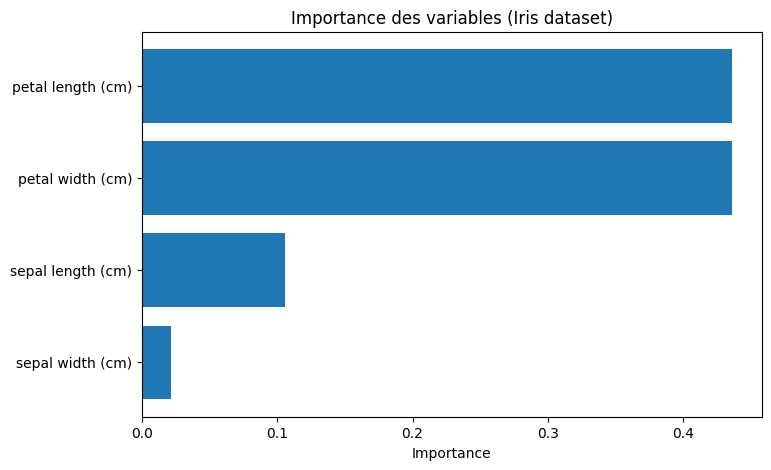

In [14]:
# Graphique
plt.figure(figsize=(8,5))
plt.barh(importance_df['Variable'], importance_df['Importance'])
plt.xlabel('Importance')
plt.title('Importance des variables (Iris dataset)')
plt.gca().invert_yaxis()
plt.show()